In [4]:
# ============================================================
# Vanilla RNN for Temperature Forecasting (Optimized Version)
# ============================================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

# 2. LOAD DATA
df = pd.read_csv('DailyDelhiClimateTrain.csv', parse_dates=['date'], index_col='date')

# Handle missing values
df = df.ffill()
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

# 3. SCALE DATA
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

# Separate scaler for target
target_scaler = MinMaxScaler()
target_scaler.fit(df[['meantemp']])

# 4. CREATE SEQUENCES (Time-series windowing)
def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])     # past 30 days
        y.append(data[i, 0])             # next day temp
    return np.array(X), np.array(y)

LOOKBACK = 30
X, y = create_sequences(scaled_data, LOOKBACK)

# Train-test split (no shuffle for time series)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [5]:

# ============================================================
# 5. BUILD BASELINE RNN
# ============================================================
model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(LOOKBACK, len(features))),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mae', metrics=['mse'])

# Train model
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)


Epoch 1/50


c:\Users\Harshita\Desktop\ML-DL lab\venv-dl\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.2549 - mse: 0.1001 - val_loss: 0.1177 - val_mse: 0.0221
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1527 - mse: 0.0379 - val_loss: 0.0559 - val_mse: 0.0051
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1057 - mse: 0.0178 - val_loss: 0.0592 - val_mse: 0.0054
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0995 - mse: 0.0154 - val_loss: 0.0548 - val_mse: 0.0048
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0843 - mse: 0.0113 - val_loss: 0.0466 - val_mse: 0.0037
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0824 - mse: 0.0109 - val_loss: 0.0535 - val_mse: 0.0043
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0828 - mse: 0.0111 - val_loss: 0.0537 - val_mse: 0.0047
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0906 - mse: 0.0127 - val_loss: 0.0457 - val_mse: 0.0037
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0669 - mse: 0.0074 - v

In [6]:

# ============================================================
# 6. PREDICTIONS & EVALUATION
# ============================================================
y_pred = model.predict(X_test)

# Convert back to actual values
y_pred_actual = target_scaler.inverse_transform(y_pred)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1,1))

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print("\nBaseline RNN Performance:")
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Baseline RNN Performance:
RMSE: 1.72, MAE: 1.33, R2: 0.91


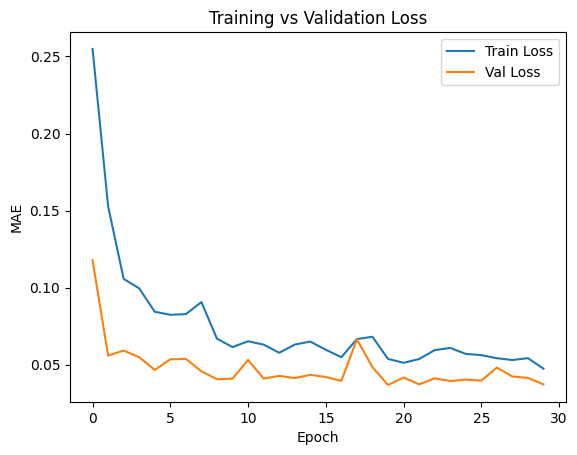

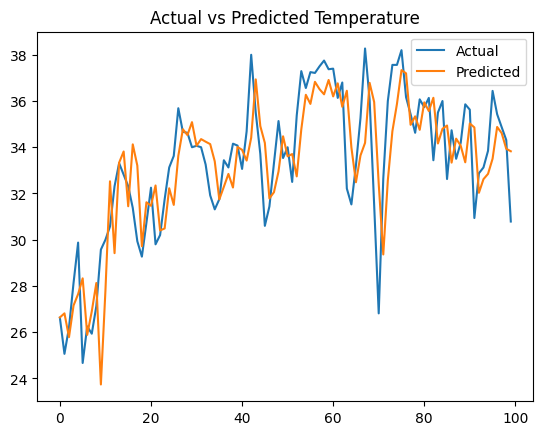

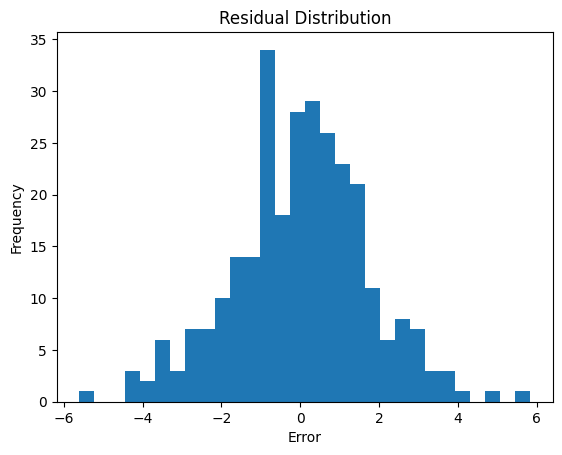

In [7]:

# ============================================================
# 7. VISUALIZATIONS (ONLY RELEVANT ONES)
# ============================================================

# (1) Training vs Validation Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

# (2) Actual vs Predicted
plt.figure()
plt.plot(y_test_actual[:100], label='Actual')
plt.plot(y_pred_actual[:100], label='Predicted')
plt.title("Actual vs Predicted Temperature")
plt.legend()
plt.show()

# (3) Residual Distribution (error analysis)
residuals = y_test_actual - y_pred_actual
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


In [8]:

# ============================================================
# 8. KERAS TUNER (HYPERPARAMETER TUNING)
# ============================================================

def build_model(hp):
    model = Sequential()

    # Tune RNN units
    units = hp.Int('units', min_value=32, max_value=128, step=32)
    model.add(SimpleRNN(units, activation='tanh', input_shape=(LOOKBACK, len(features))))

    # Tune dropout
    dropout = hp.Float('dropout', 0.1, 0.5, step=0.1)
    model.add(Dropout(dropout))

    # Tune dense layer
    dense_units = hp.Int('dense_units', 16, 64, step=16)
    model.add(Dense(dense_units, activation='relu'))

    model.add(Dense(1))

    # Tune learning rate
    lr = hp.Choice('lr', [1e-2, 1e-3, 1e-4])

    model.compile(optimizer=Adam(lr), loss='mae', metrics=['mse'])
    return model

# Initialize tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,   # keep small for exam/laptop
    directory='tuner_dir',
    project_name='rnn_tuning'
)

# Run tuning
tuner.search(
    X_train, y_train,
    epochs=30,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)],
    shuffle=False,
    verbose=1
)

# Best model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate tuned model
y_pred_tuned = best_model.predict(X_test)
y_pred_tuned_actual = target_scaler.inverse_transform(y_pred_tuned)

rmse_t = np.sqrt(mean_squared_error(y_test_actual, y_pred_tuned_actual))
mae_t = mean_absolute_error(y_test_actual, y_pred_tuned_actual)
r2_t = r2_score(y_test_actual, y_pred_tuned_actual)

print("\nTuned RNN Performance:")
print(f"RMSE: {rmse_t:.2f}, MAE: {mae_t:.2f}, R2: {r2_t:.2f}")

Trial 5 Complete [00h 00m 06s]
val_loss: 0.04270992428064346

Best val_loss So Far: 0.04270992428064346
Total elapsed time: 00h 00m 19s
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

c:\Users\Harshita\Desktop\ML-DL lab\venv-dl\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Tuned RNN Performance:
RMSE: 2.07, MAE: 1.65, R2: 0.87
